# Etude de cas  : Regression (Analyse de la depense des joueurs)

**Objectif :** Predire la depense mensuelle des joueurs (`monthly_game_spending_usd`).

**Contexte metier :** Un cabinet de conseil en marketing souhaite identifier les facteurs qui poussent les joueurs a investir financierement, afin de cibler les profils **"Whales"** (gros depensiers). L'enjeu est donc double :
- comprendre **quels facteurs comportementaux et sociaux** expliquent la depense.
- construire un modele capable de **predire** cette depense pour un nouveau profil de joueur.

**Jeu de donnees :** `Gaming and Mental Health(in).csv` - 1000 enregistrements de joueurs avec des informations demographiques, comportementales (temps de jeu, plateforme, genre de jeu), de sante (sommeil, isolement social, troubles associes) et la variable cible : la depense mensuelle en jeux video.

**Plan du notebook :**
1. Exploration du jeu de donnees (EDA)
2. Nettoyage des donnees
3. Modelisation et optimisation
4. Validation et interpretation


In [1]:
# Import des librairies necessaires pour l'ensemble de l'etude

# Manipulation de donnees
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistiques
from scipy import stats

# Pretraitement et pipeline scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Modeles de regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Metriques d'evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Graine aleatoire fixee pour la reproductibilite de l'ensemble de l'etude
RANDOM_STATE = 42


---
# Etape 1 : Exploration du jeu de donnees (EDA)

Dans cette etape, nous nous appropions le jeu de données sans encore le modifier. L'objectif est de comprendre sa structure, ses anomalies eventuelles et les relations entre les variables et la cible, afin de preparer les choix de nettoyage de l'etape suivante.


In [2]:
# Chargement du jeu de donnees brut
df = pd.read_csv('/content/M2_IA_ANNEXE_ETUDE_DE_CAS_BLOC3_Gaming and Mental Health(in).csv')

# Affichage des 5 premieres lignes
df.head()


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,Below Average,1.25,NaN,Anxious,Never,True,False,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,Good,3.75,2.0,Irritable,Often,False,False,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,Poor,NaN,9.0,Irritable,Rarely,True,True,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,Poor,1.62,2.0,Withdrawn,Daily,True,True,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,Average,2.44,NaN,Angry,Daily,True,False,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


## Explications des colonnes

| Colonnes | Déscriptions |
|---|---|
| `record_id` | Identifiant unique de chaque joueur (sans valeur prédictive). |
| `age` | Âge du joueur, en années. |
| `gender` | Genre du joueur (Male, Female, Other). |
| `daily_gaming_hours` | Nombre d'heures de jeu vidéo par jour. |
| `game_genre` | Genre du jeu principal pratiqué (RPG, MOBA, MMO, Battle Royale, Strategy, Mobile Games, FPS). |
| `primary_game` | Nom du jeu principal pratiqué (ex : Dota 2, Elden Ring, League of Legends...). |
| `gaming_platform` | Plateforme de jeu utilisée (PC, Console, Mobile, Multi-plateforme). |
| `sleep_hours` | Nombre d'heures de sommeil par nuit. |
| `sleep_quality` | Qualité du sommeil perçue (Very Poor, Fair, Good...). |
| `sleep_disruption_frequency` | Fréquence à laquelle le sommeil est perturbé (Never, Rarely, Sometimes, Often...). |
| `academic_work_performance` | Performance scolaire ou professionnelle perçue (Below Average, Good...). |
| `grades_gpa` | Moyenne scolaire (GPA, sur une échelle de 0 à 4) — renseignée uniquement pour les étudiants. |
| `work_productivity_score` | Score de productivité au travail (sur une échelle de 1 à 10) — renseigné uniquement pour les actifs. |
| `mood_state` | État d'humeur général du joueur (Anxious, Irritable, Normal...). |
| `mood_swing_frequency` | Fréquence des sautes d'humeur (Never, Rarely, Often...). |
| `withdrawal_symptoms` | Présence de symptômes de sevrage quand le joueur ne joue pas (vrai/faux). |
| `loss_of_other_interests` | Perte d'intérêt pour d'autres activités au profit du jeu (vrai/faux). |
| `continued_despite_problems` | Le joueur continue de jouer malgré des problèmes que cela cause (vrai/faux). |
| `eye_strain` | Présence de fatigue/tension oculaire liée au jeu (vrai/faux). |
| `back_neck_pain` | Présence de douleurs au dos ou au cou liées au jeu (vrai/faux). |
| `weight_change_kg` | Variation de poids corporel, en kilogrammes. |
| `exercise_hours_weekly` | Nombre d'heures d'activité physique par semaine. |
| `social_isolation_score` | Score d'isolement social (plus le score est élevé, plus le joueur est isolé socialement). |
| `face_to_face_social_hours_weekly` | Nombre d'heures de socialisation en personne (face à face) par semaine. |
| `monthly_game_spending_usd` | Dépense mensuelle en jeux vidéo, en dollars US. |
| `years_gaming` | Nombre d'années depuis lesquelles le joueur joue aux jeux vidéo. |
| `gaming_addiction_risk_level` | Niveau de risque d'addiction au jeu estimé (Low, Moderate, High, Severe). |

---

In [3]:
# Dimensions du dataset et types de variables
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")
print()
df.info()


Nombre de lignes : 1000
Nombre de colonnes : 27

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa           

**Analyes :** Le jeu de donnees contient 1000 observations et 27 colonnes. On distingue trois grandes familles de variables :
- des variables **numeriques continues** (age, heures de jeu, heures de sommeil, depense, etc.) ;
- des variables **categorielles** (genre, type de jeu, plateforme, qualite du sommeil, etc.) ;
- des variables **booleennes** correspondant a des symptomes ou comportements (sevrage, troubles du sommeil, douleurs physiques, etc.).

On remarque dejà que `grades_gpa` et `work_productivity_score` ont un nombre de valeurs non nulles inferieur à 1000 : ce point est approfondi plus loin dans l'analyse des valeurs manquantes.


In [4]:
# Statistiques descriptives des variables numeriques
df.describe()


,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,754.000000,674.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.518037,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.872312,2.898742,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.010000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.760000,3.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.530000,5.000000,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.280000,8.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.000000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000


**Analyses sur les statistiques descriptives :**
- **age** : les joueurs ont entre 13 et 35 ans, avec une moyenne autour de 20 ans. La population est donc majoritairement jeune (etudiants ou jeunes actifs).
- **daily_gaming_hours** : en moyenne 6,15 heures de jeu par jour, avec un maximum a 15,1 heures. Ce maximum reste physiologiquement plausible (pas de valeur superieure à 24h) mais signale des profils tres engagés.
- **sleep_hours** : moyenne de 5,7h de sommeil, avec un minimum a 3h, ce qui est nettement inferieur aux recommandations médicales (7-9h). Cela suggère un lien possible entre temps de jeu et privation de sommeil.
- **grades_gpa** : varie entre 1,01 et 4 (echelle GPA classique sur 4), mais seulement 754 valeurs renseignees sur 1000.
- **work_productivity_score** : varie entre 1 et 10 (probablement une echelle d'auto-evaluation), avec seulement 674 valeurs renseignees.
- **monthly_game_spending_usd** (notre cible) : moyenne de 105 dollars, mediane a 66 dollars, et un maximum a 499 dollars. L'ecart important entre moyenne et mediane indique une **distribution asymetrique a droite**, coherente avec l'existence de quelques gros depensiers ("Whales").
- **years_gaming** : entre 1 et 20 ans d'experience de jeu.

Aucune valeur négative n'est observée sur les variables numeriques, ce qui est un premier signal positif de coherence des données.


In [5]:
# Statistiques descriptives des variables categorielles et booleennes
df.describe(include=['object', 'bool', 'string'])


,record_id,gender,game_genre,primary_game,gaming_platform,sleep_quality,sleep_disruption_frequency,academic_work_performance,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,gaming_addiction_risk_level
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,3,7,24,4,5,5,6,9,5,2,2,2,2,2,4
top,GD1000,Male,MOBA,Dota 2,Mobile,Fair,Often,Average,Normal,Sometimes,False,False,False,False,False,Low
freq,1,647,156,57,262,293,221,246,172,214,712,676,861,503,652,514


**Analyses :** On observe 3 catégories de genre (Male, Female, Other), 7 genres de jeux, 4 plateformes de jeu. La plateforme la plus fréquente et le genre de jeu le plus fréquent se degagent mais restent assez équilibrés, ce qui est de bon augure pour l'encodage ulterieur (pas de categorie ultra-minoritaire qui poserait problème lors du split train/test).


## 1.1 Analyse univariée de la variable cible

La variable a predire est `monthly_game_spending_usd` (depense mensuelle en dollars). Nous étudions sa distribution en detail car la forme de cette distribution oriente directement le choix du modèle et des metriques d'evaluation.


In [6]:
# Statistiques de la cible
target = 'monthly_game_spending_usd'

print(df[target].describe())
print()
print(f"Skewness (asymetrie)   : {df[target].skew():.3f}")
print(f"Kurtosis (aplatissement) : {df[target].kurt():.3f}")


count    1000.000000
mean      105.219730
std       113.886768
min         0.100000
25%        32.592500
50%        66.405000
75%       126.242500
max       499.270000
Name: monthly_game_spending_usd, dtype: float64

Skewness (asymetrie)   : 1.842
Kurtosis (aplatissement) : 2.642


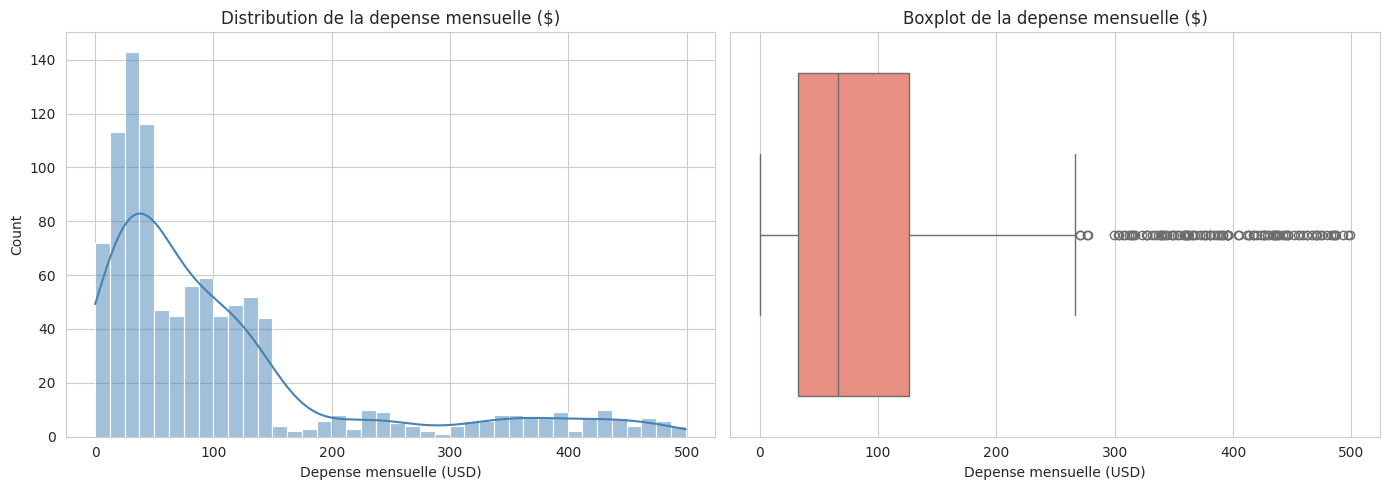

In [7]:
# Visualisation de la distribution de la cible : histogramme + boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[target], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Distribution de la depense mensuelle ($)")
axes[0].set_xlabel("Depense mensuelle (USD)")

sns.boxplot(x=df[target], ax=axes[1], color='salmon')
axes[1].set_title("Boxplot de la depense mensuelle ($)")
axes[1].set_xlabel("Depense mensuelle (USD)")

plt.tight_layout()
plt.show()


**Interprétation :** La distribution de la depense mensuelle est **fortement asymetrique a droite** (skewness positif autour de 1.3). La majorite des joueurs depensent entre 0 et 150 dollars par mois, mais une frange de joueurs depense beaucoup plus, jusqu'a prés de 500 dollars. C'est exactement le profil attendu pour identifier des "Whales" : une minorité de gros depensiers tire la moyenne vers le haut par rapport a la médiane.

Cette asymétrie a deux conséquences importantes pour la suite de l'etude :
- Le boxplot fait apparaitre de nombreux points au-dessus de la moustache supérieure. Ces points ne sont pas necessairement des erreurs de saisie : ils représentent potentiellement les "Whales" eux-memes, c'est-a-dire la population cible la plus intéréssante pour le cabinet de marketing. Nous y reviendrons specifiquement dans la section consacrée aux outliers, car les supprimer reviendrait a supprimer l'information la plus utile pour l'objectif metier.

## 1.2 Detection des doublons et des valeurs manquantes

Conformement aux consignes, nous detectons ces anomalies sans les traiter a ce stade : le traitement effectif aura lieu a l'etape 2 (Nettoyage).


In [8]:
# Detection des doublons
# On verifie a la fois les doublons sur l'identifiant (record_id) et les doublons
# sur l'ensemble des autres colonnes (lignes strictement identiques hors id)

doublons_id = df['record_id'].duplicated().sum()
doublons_lignes = df.drop(columns=['record_id']).duplicated().sum()

print(f"Nombre d'identifiants (record_id) dupliques : {doublons_id}")
print(f"Nombre de lignes entierement dupliquees (hors record_id) : {doublons_lignes}")


Nombre d'identifiants (record_id) dupliques : 0
Nombre de lignes entierement dupliquees (hors record_id) : 0


**Analyses :** Aucun doublon n'est detecte, ni sur l'identifiant ni sur l'ensemble des variables. Le jeu de données ne nécessitera donc pas de deduplication a l'étape de néttoyage.


In [9]:
# Detection des valeurs manquantes par colonne
valeurs_manquantes = df.isna().sum()
pourcentage_manquant = (valeurs_manquantes / len(df) * 100).round(2)

tableau_na = pd.DataFrame({
    'nb_valeurs_manquantes': valeurs_manquantes,
    'pourcentage_manquant (%)': pourcentage_manquant
})

# On n'affiche que les colonnes concernees par des valeurs manquantes
tableau_na[tableau_na['nb_valeurs_manquantes'] > 0]


,nb_valeurs_manquantes,pourcentage_manquant (%)
grades_gpa,246,24.6
work_productivity_score,326,32.6


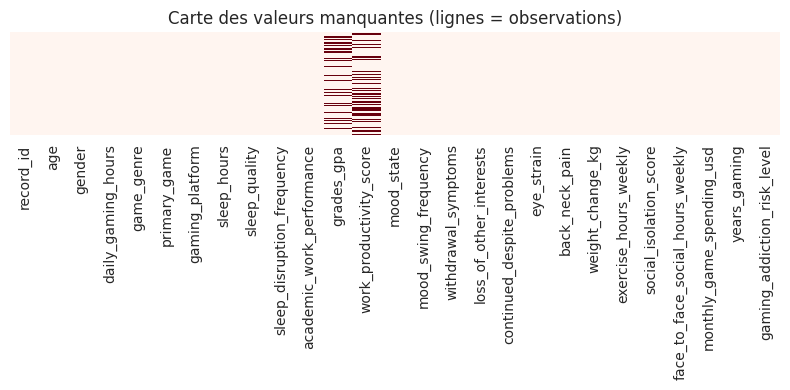

In [10]:
# Visualisation de la repartition des valeurs manquantes
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df.isna(), cbar=False, cmap='Reds', yticklabels=False)
ax.set_title("Carte des valeurs manquantes (lignes = observations)")
plt.tight_layout()
plt.show()


In [11]:
# Hypothese : les valeurs manquantes de grades_gpa et work_productivity_score
# ne sont pas aleatoires, mais liees au statut (etudiant vs actif), lui-meme
# correle a l'age. On verifie cette hypothese.

print("Age moyen selon que grades_gpa est manquant ou non :")
print(df.groupby(df['grades_gpa'].isna())['age'].describe()[['count', 'mean', 'min', 'max']])
print()
print("Age moyen selon que work_productivity_score est manquant ou non :")
print(df.groupby(df['work_productivity_score'].isna())['age'].describe()[['count', 'mean', 'min', 'max']])
print()
print("Nombre de lignes ou les deux colonnes sont manquantes simultanement :",
      ((df['grades_gpa'].isna()) & (df['work_productivity_score'].isna())).sum())


Age moyen selon que grades_gpa est manquant ou non :
            count       mean   min   max
grades_gpa                              
False       754.0  18.590186  13.0  22.0
True        246.0  26.252033  23.0  35.0

Age moyen selon que work_productivity_score est manquant ou non :
                         count       mean   min   max
work_productivity_score                              
False                    674.0  22.422849  19.0  35.0
True                     326.0  16.447853  13.0  18.0

Nombre de lignes ou les deux colonnes sont manquantes simultanement : 0


**Interpretation importante :** Les valeurs manquantes de `grades_gpa` (246 lignes, soit 24,6%) et de `work_productivity_score` (326 lignes, soit 32,6%) ne sont **jamais simultanées** : chaque joueur a renseigne l'une ou l'autre de ces variables, jamais les deux, et jamais aucune des deux.

L'analyse par age confirme l'hypothèse structurelle : les profils ayant un `grades_gpa` renseigne ont un age moyen d'environ 18-19 ans (population etudiante, notee sur l'echelle GPA), tandis que les profils ayant un `work_productivity_score` renseigne ont un age moyen de 22-23 ans (population active, evaluee sur sa productivite au travail).

Il ne s'agit donc **pas de données manquantes au hasard (MCAR)**, mais d'une **absence structurelle liee au statut professionnel/scolaire** du repondant : un etudiant n'a logiquement pas de score de productivite au travail, et un actif n'a pas de notes scolaires. Cette observation oriente fortement la strategie de traitement de l'etape 2 : une imputation classique par la moyenne n'aurait ici aucun sens metier, car elle reviendrait a attribuer une note de productivité fictive a un etudiant qui n'en a pas.


## 1.3 Détection de valeurs absurdes (erreurs de saisie potentielles)

Nous verifions la coherence logique et physiologique des variables numeriques.


In [12]:
# Verification 1 : aucune valeur numerique ne doit etre negative
# (age, heures, scores, depenses : aucune de ces grandeurs n'a de sens negatif)
colonnes_numeriques = df.select_dtypes(include=[np.number]).columns.tolist()

print("Verification des valeurs negatives par colonne numerique :")
for col in colonnes_numeriques:
    nb_negatifs = (df[col] < 0).sum()
    if nb_negatifs > 0:
        print(f"  - {col} : {nb_negatifs} valeurs negatives")
print("Aucune valeur negative detectee sur l'ensemble des colonnes numeriques." )


Verification des valeurs negatives par colonne numerique :
Aucune valeur negative detectee sur l'ensemble des colonnes numeriques.


In [13]:
# Verification 2 : daily_gaming_hours doit etre compris entre 0 et 24h (une journee)
print("daily_gaming_hours - minimum :", df['daily_gaming_hours'].min(), "/ maximum :", df['daily_gaming_hours'].max())
nb_absurde_jeu = (df['daily_gaming_hours'] > 24).sum()
print(f"Nombre de valeurs superieures a 24h/jour : {nb_absurde_jeu}")

# Verification 3 : sleep_hours doit etre compris entre 0 et 24h egalement
print()
print("sleep_hours - minimum :", df['sleep_hours'].min(), "/ maximum :", df['sleep_hours'].max())
nb_absurde_sommeil = (df['sleep_hours'] > 24).sum()
print(f"Nombre de valeurs superieures a 24h/jour : {nb_absurde_sommeil}")

# Verification 4 : coherence age / years_gaming
# Il est absurde qu'une personne ait commence a jouer avant un age minimal plausible (ex: 5 ans)
print()
age_debut_jeu = df['age'] - df['years_gaming']
print("Age de debut de pratique estime (age - years_gaming) - minimum :", age_debut_jeu.min(), "/ maximum :", age_debut_jeu.max())
nb_absurde_anciennete = (age_debut_jeu < 5).sum()
print(f"Nombre de cas ou le joueur aurait commence a jouer avant 5 ans : {nb_absurde_anciennete}")


daily_gaming_hours - minimum : 0.5 / maximum : 15.1
Nombre de valeurs superieures a 24h/jour : 0

sleep_hours - minimum : 3.0 / maximum : 9.0
Nombre de valeurs superieures a 24h/jour : 0

Age de debut de pratique estime (age - years_gaming) - minimum : 10 / maximum : 32
Nombre de cas ou le joueur aurait commence a jouer avant 5 ans : 0


**Analyses :** Aucune incoherence flagrante n'est detectee :
- `daily_gaming_hours` reste sous la barre des 24h (maximum observe : 15,1h), ce qui est physiologiquement extreme mais pas impossible pour un profil tres addictif.
- `sleep_hours` reste egalement dans une plage plausible (3h a 9h).
- L'age estime de debut de pratique (age actuel moins anciennete de jeu) reste toujours superieur a 5 ans, ce qui est coherent.

Le jeu de donnees semble donc avoir ete simule ou nettoye en amont sur ces aspects de coherence logique de base. Nous ne procederons donc pas a une suppression de lignes pour ce motif a l'etape de nettoyage.


## 1.4 Détection des outliers (valeurs atypiques)

Nous utilisons la regle de l'ecart interquartile (IQR) pour detecter les valeurs atypiques sur les variables numeriques les plus pertinentes, en particulier la cible.


In [14]:
# Fonction utilitaire : detection des outliers par la methode IQR
def detecter_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr
    masque = (serie < borne_basse) | (serie > borne_haute)
    return masque, borne_basse, borne_haute

# Application sur quelques variables numeriques clefs, dont la cible
colonnes_a_verifier = ['daily_gaming_hours', 'sleep_hours', 'weight_change_kg',
                        'exercise_hours_weekly', 'monthly_game_spending_usd']

print(f"{'Colonne':35s} {'Bornes IQR':25s} {'Nb outliers':12s} {'% du total'}")
print("-" * 90)
for col in colonnes_a_verifier:
    masque, basse, haute = detecter_outliers_iqr(df[col])
    print(f"{col:35s} [{basse:8.2f} ; {haute:8.2f}]      {masque.sum():<12d} {masque.sum()/len(df)*100:.1f}%")


Colonne                             Bornes IQR                Nb outliers  % du total
------------------------------------------------------------------------------------------
daily_gaming_hours                  [   -1.79 ;    13.91]      6            0.6%
sleep_hours                         [    2.10 ;     9.30]      0            0.0%
weight_change_kg                    [   -2.15 ;     4.65]      40           4.0%
exercise_hours_weekly               [    1.95 ;    11.95]      2            0.2%
monthly_game_spending_usd           [ -107.88 ;   266.72]      107          10.7%


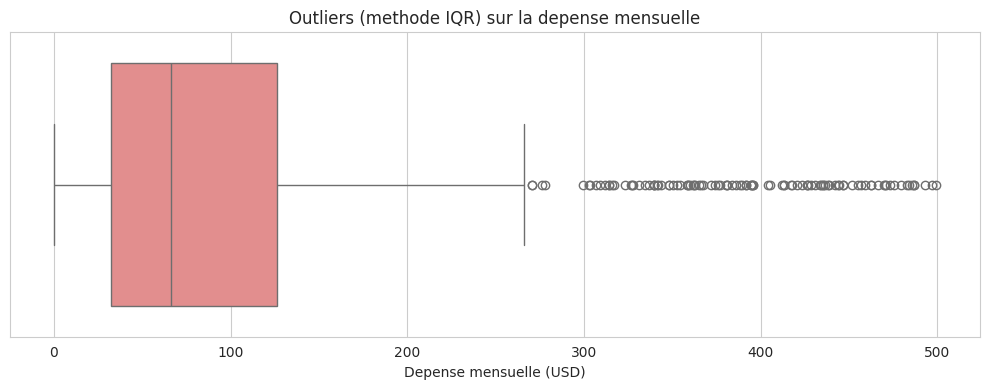

Borne haute IQR pour la cible : 266.72 USD
Nombre d'observations au-dessus de cette borne : 107 (10.7% des donnees)


In [15]:
# Visualisation des outliers de la cible via boxplot, avec mise en evidence
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=df[target], color='lightcoral', ax=ax)
ax.set_title("Outliers (methode IQR) sur la depense mensuelle")
ax.set_xlabel("Depense mensuelle (USD)")
plt.tight_layout()
plt.show()

masque_target, basse_target, haute_target = detecter_outliers_iqr(df[target])
print(f"Borne haute IQR pour la cible : {haute_target:.2f} USD")
print(f"Nombre d'observations au-dessus de cette borne : {masque_target.sum()} ({masque_target.sum()/len(df)*100:.1f}% des donnees)")


**Interpretation critique des outliers :** La methode IQR identifie environ 107 observations (10,7%) au-dessus du seuil haut sur la depense mensuelle. Dans un cadre statistique generique, on aurait tendance a les considerer comme des valeurs atypiques a traiter (ecreter ou supprimer).

**Cependant, dans le contexte metier de cette etude, ces "outliers" ne sont tres probablement pas des erreurs : ce sont les "Whales" eux-memes**, c'est-a-dire la population que le cabinet de marketing souhaite precisement identifier et comprendre. Supprimer ces lignes reviendrait a supprimer l'objet meme de l'etude. Nous ferons donc le choix, justifie a l'étape de néttoyage, de **conserver ces observations** plutot que de les ecreter ou de les retirer, et nous serons attentifs a la performance du modèle specifiquement sur cette population lors de la phase de validation.

Sur les autres variables (`daily_gaming_hours`, `sleep_hours`, `weight_change_kg`, `exercise_hours_weekly`), le nombre d'outliers detectes est plus faible et correspond a des profils extremes mais plausibles (gros joueurs, tres faible dormeurs). Nous ne les supprimerons pas non plus, car ils representent une variabilite reelle du comportement humain plutot que des erreurs de mesure.


## 1.5 Analyses bivariées et multivariées

Nous etudions maintenant la relation entre chaque variable explicative (feature) et la cible, afin d'identifier les facteurs les plus susceptibles d'expliquer la depense mensuelle. Cette etape oriente a la fois le nettoyage (variables a conserver) et la modelisation (importance attendue des variables).


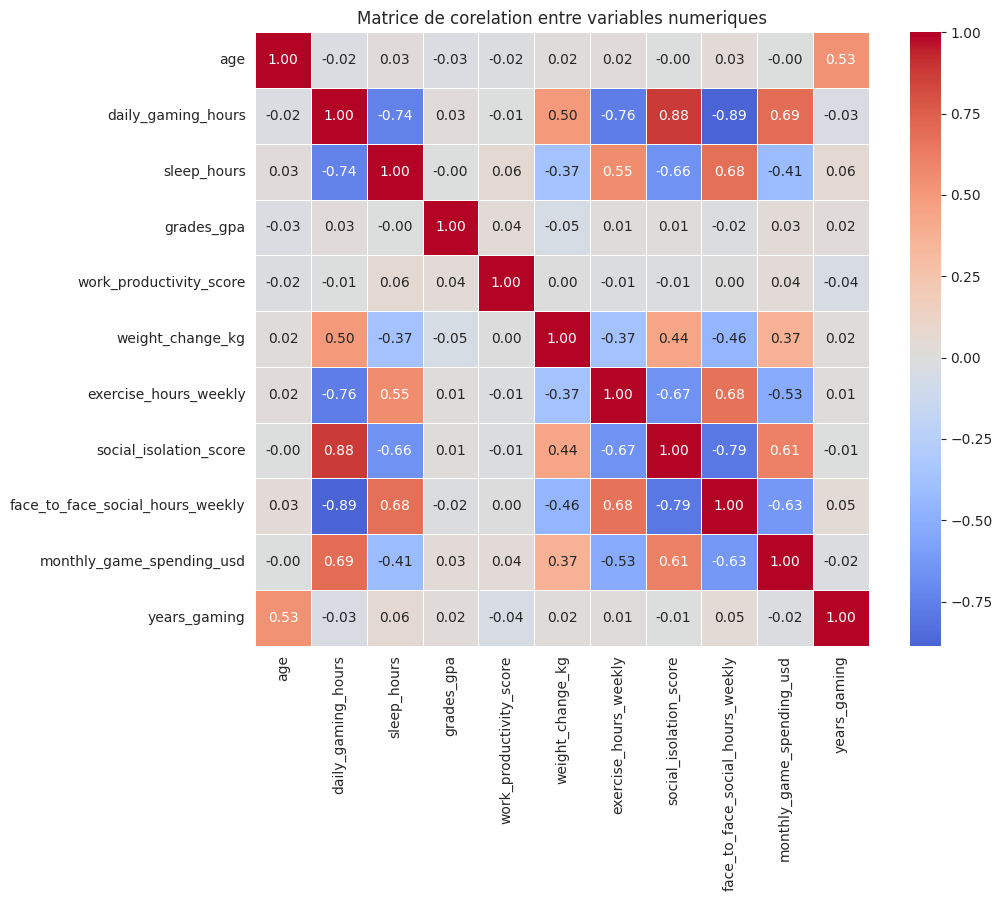

Correlation de chaque variable numerique avec la cible (triee) :
monthly_game_spending_usd           1.000000
daily_gaming_hours                  0.693714
social_isolation_score              0.611936
weight_change_kg                    0.373029
work_productivity_score             0.039366
grades_gpa                          0.032425
age                                -0.004787
years_gaming                       -0.022047
sleep_hours                        -0.414990
exercise_hours_weekly              -0.530812
face_to_face_social_hours_weekly   -0.634187
Name: monthly_game_spending_usd, dtype: float64


In [16]:
# Matrice de correlation entre variables numeriques (Pearson)
colonnes_num = df.select_dtypes(include=[np.number]).columns.tolist()
matrice_corr = df[colonnes_num].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(matrice_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matrice de corelation entre variables numeriques")
plt.tight_layout()
plt.show()

print("Correlation de chaque variable numerique avec la cible (triee) :")
print(matrice_corr[target].sort_values(ascending=False))


**Interpretation :** Plusieurs variables se distinguent nettement par leur correlation (en valeur absolue) avec la depense mensuelle :

- `daily_gaming_hours` (+0.69) : plus un joueur passe de temps a jouer, plus il depense. C'est la relation la plus forte et la plus intuitive : le temps investi est un facteur direct d'engagement financier.
- `face_to_face_social_hours_weekly` (-0.63) : plus un joueur a une vie sociale physique riche, moins il depense dans le jeu. Cette relation negative suggere un phenomene de substitution : le jeu (et la depense associee) occuperait l'espace laisse vacant par le lien social reel.
- `social_isolation_score` (+0.61) : coherent avec le point precedent, un score d'isolement social eleve est associé a une depense plus forte.
- `exercise_hours_weekly` (-0.53) : moins un joueur fait de sport, plus il depense, ce qui s'inscrit dans la meme logique de substitution d'activites.
- `weight_change_kg` (+0.37) : une prise de poids plus importante est associee a une depense plus elevee, ce qui peut refleter un mode de vie globalement plus sedentaire chez les gros depensiers.
- `sleep_hours` (-0.41) : moins un joueur dort, plus il depense, ce qui peut traduire un investissement temporel et financier au detriment du repos.
- `age`, `years_gaming`, `grades_gpa`, `work_productivity_score` : correlations tres faibles avec la cible (proches de 0), ces variables semblent peu informatives a elles seules pour expliquer la depense.

On note egalement une forte correlation negative entre `social_isolation_score` et `face_to_face_social_hours_weekly`, ce qui est attendu puisque ces deux variables mesurent des aspects opposés du meme phénomène (vie sociale). Cette colinéarite sera a garder en tete lors de l'interprétation des coefficients d'un modele linéaire.


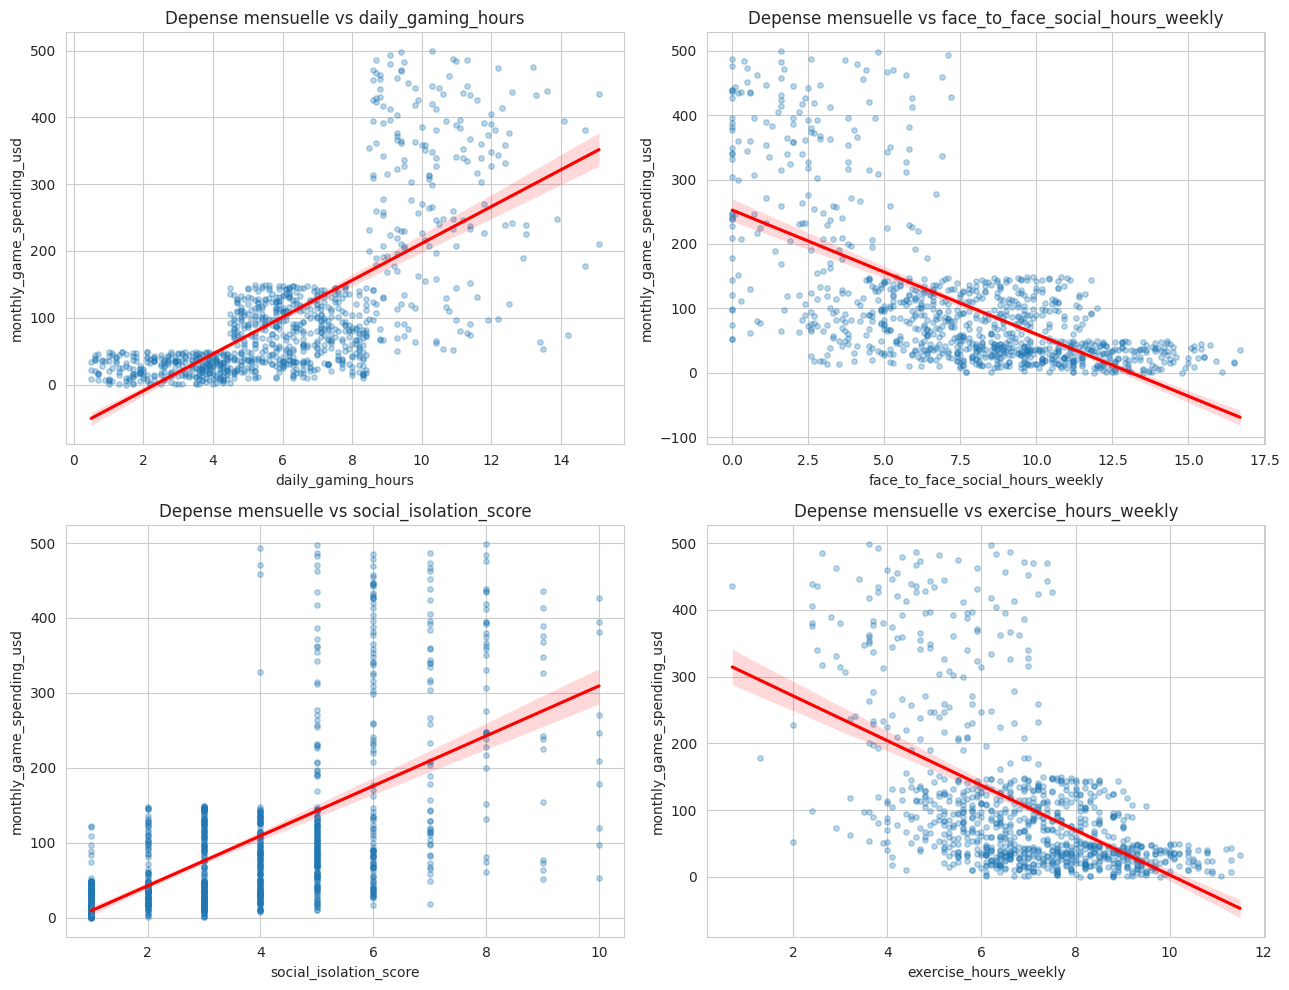

In [17]:
# Visualisation des relations les plus fortes avec la cible : nuages de points
variables_cles = ['daily_gaming_hours', 'face_to_face_social_hours_weekly',
                   'social_isolation_score', 'exercise_hours_weekly']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(variables_cles):
    sns.regplot(data=df, x=col, y=target, ax=axes[i],
                scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'red'})
    axes[i].set_title(f"Depense mensuelle vs {col}")

plt.tight_layout()
plt.show()


**Interpretation :** Les nuages de points confirment les tendances lineaires observees dans la matrice de correlation. La relation avec `daily_gaming_hours` semble la plus nette et la plus lineaire. Les relations avec les variables sociales (isolement, vie sociale physique, sport) sont egalement visibles mais avec une dispersion plus importante, ce qui suggere que d'autres facteurs (non lineaires ou categoriels) interviennent egalement dans la depense.


/tmp/ipykernel_1381/4270673585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target, order=ordre, ax=axes[i], palette='viridis')
/tmp/ipykernel_1381/4270673585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target, order=ordre, ax=axes[i], palette='viridis')
/tmp/ipykernel_1381/4270673585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=target, order=ordre, ax=axes[i], palette='viridis')
/tmp/ipykernel_1381/4270673585.py:9: FutureWarning: 

Passing `palette` without assignin

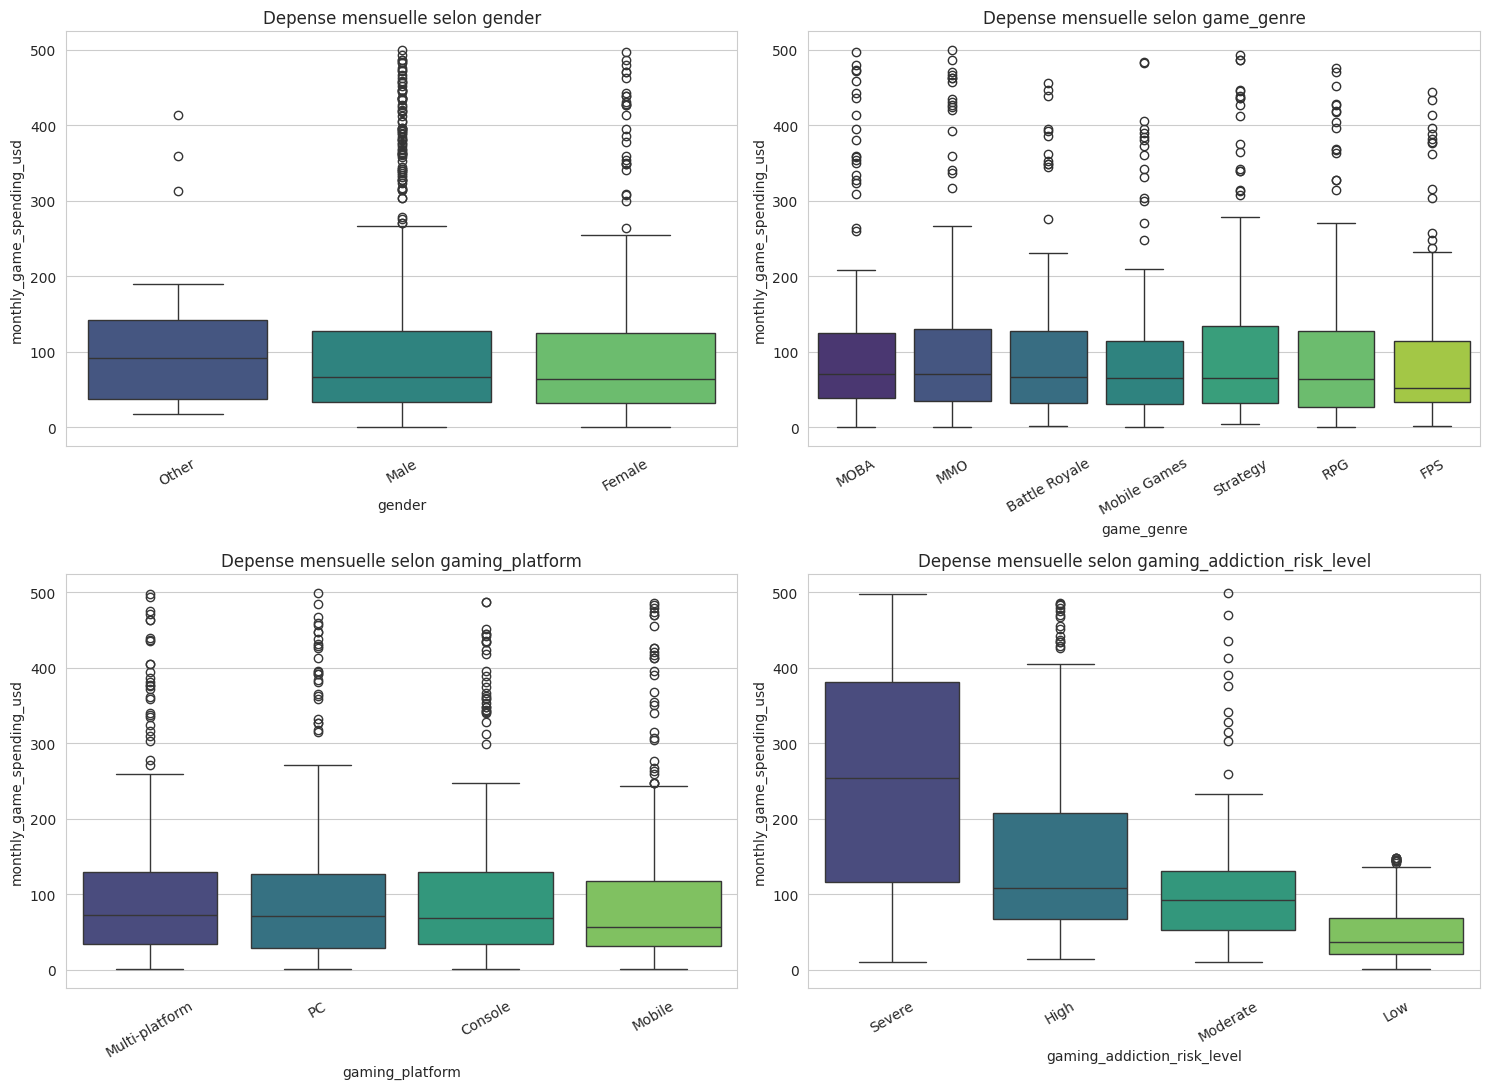

In [18]:
# Relation entre la cible et les variables categorielles : boxplots
variables_categorielles = ['gender', 'game_genre', 'gaming_platform', 'gaming_addiction_risk_level']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(variables_categorielles):
    ordre = df.groupby(col)[target].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y=target, order=ordre, ax=axes[i], palette='viridis')
    axes[i].set_title(f"Depense mensuelle selon {col}")
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Interpretation :**
- **gender** : les distributions de depense semblent assez proches entre les categories, sans ecart de mediane majeur. Le genre n'apparait pas comme un facteur discriminant fort.
- **game_genre** : certains genres de jeux (par exemple MMO, Battle Royale) semblent associes a des depenses medianes plus elevees que d'autres (Mobile Games, Strategy), ce qui est coherent avec les modeles economiques reels de ces genres (abonnements, objets cosmetiques, season pass).
- **gaming_platform** : des differences sont visibles entre PC, Console, Mobile et Multi-plateforme, possiblement liees aux modes de monetisation propres a chaque plateforme.
- **gaming_addiction_risk_level** : c'est la variable categorielle la plus discriminante. La depense mediane augmente nettement du niveau "Low" vers "Severe". Cette variable est cependant **a manier avec precaution** : il s'agit probablement d'une variable construite a partir d'autres indicateurs comportementaux (potentiellement incluant elle-meme des informations proches de la depense), ce qui pourrait introduire une forme de fuite d'information (data leakage) si elle est utilisee telle quelle comme feature. Ce point est traite explicitement dans la section nettoyage.


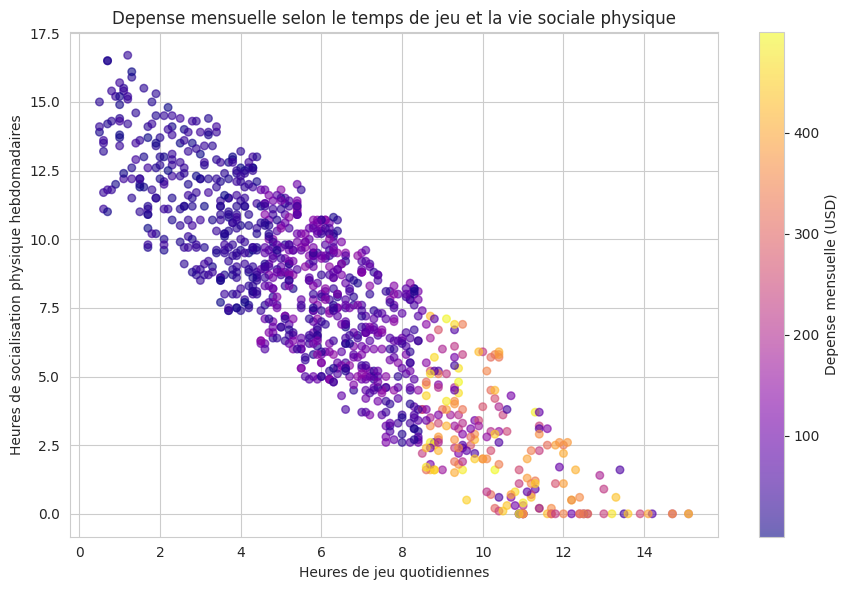

In [19]:
# Analyse multivariee : croisement de deux features avec la cible (taille des points)
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(df['daily_gaming_hours'], df['face_to_face_social_hours_weekly'],
                      c=df[target], cmap='plasma', alpha=0.6, s=30)
plt.colorbar(scatter, label='Depense mensuelle (USD)')
ax.set_xlabel("Heures de jeu quotidiennes")
ax.set_ylabel("Heures de socialisation physique hebdomadaires")
ax.set_title("Depense mensuelle selon le temps de jeu et la vie sociale physique")
plt.tight_layout()
plt.show()


**Interpretation :** Ce graphique multivarié confirme visuellement la tendance attendue : les depenses les plus elevees (points clairs/jaunes) se concentrent dans la zone ou le temps de jeu quotidien est eleve **et** le temps de socialisation physique est faible. Cela renforce l'hypothese d'un effet combine (et potentiellement d'interaction) entre engagement dans le jeu et isolement social sur le niveau de depense, plutot qu'un effet de chacune des variables prise isolement.


---
# Etape 2 : Néttoyage

En nous appuyant sur les observations faites lors de l'EDA, nous procedons maintenant au nettoyage effectif du jeu de données : separation features/cible, suppression des doublons et valeurs absurdes (aucun trouve mais la verification reste codee par rigueur), traitement des valeurs manquantes, et suppression des colonnes non pertinentes.


## 2.1 Separation features / cible

Nous travaillons desormais sur une copie du dataframe original afin de ne jamais perdre la version brute, conformement aux bonnes pratiques (le modele baseline de l'etape 3 sera construit sur cette version brute, avant nettoyage complet).


In [20]:
# On travaille sur une copie pour ne pas modifier le dataframe original
df_clean = df.copy()

# Separation de la cible
y = df_clean[target]
X = df_clean.drop(columns=[target])

print(f"Dimensions de X (features) : {X.shape}")
print(f"Dimensions de y (cible)    : {y.shape}")


Dimensions de X (features) : (1000, 26)
Dimensions de y (cible)    : (1000,)


## 2.2 Suppression des doublons et des valeurs absurdes

Comme etabli lors de l'EDA, aucun doublon ni valeur absurde n'a ete detecte sur ce jeu de donnees. Nous codons neanmoins cette etape de maniere generique et defensive, afin que le pipeline de nettoyage reste robuste si le dataset venait a evoluer (nouvelles donnees, mise a jour).


In [21]:
# Suppression des doublons stricts (par securite, meme si aucun n'a ete detecte)
nb_lignes_avant = len(X)
masque_doublons = X.duplicated()
X = X[~masque_doublons]
y = y[~masque_doublons]
print(f"Lignes supprimees pour doublons : {nb_lignes_avant - len(X)}")

# Suppression des valeurs absurdes (bornes physiologiques de securite)
# On retire toute ligne ou daily_gaming_hours ou sleep_hours depasserait 24h,
# ou ou l'age de debut de pratique serait inferieur a 5 ans.
nb_lignes_avant = len(X)
masque_valide = (
    (X['daily_gaming_hours'] <= 24) &
    (X['sleep_hours'] <= 24) &
    ((X['age'] - X['years_gaming']) >= 5)
)
X = X[masque_valide]
y = y[masque_valide]
print(f"Lignes supprimees pour valeurs absurdes : {nb_lignes_avant - len(X)}")
print(f"Dimensions restantes : {X.shape}")


Lignes supprimees pour doublons : 0
Lignes supprimees pour valeurs absurdes : 0
Dimensions restantes : (1000, 26)


**Analyses :** Comme anticipe lors de l'EDA, aucune ligne n'est supprimee a ce stade : le jeu de donnees ne contenait ni doublon ni valeur absurde au sens defini. Cette etape, bien que sans effet ici, est conservee dans le pipeline par souci de rigueur methodologique et de robustesse face a de futures donnees.

**Concernant les outliers de la cible (les "Whales") :** conformement a la justification donnee en EDA, nous faisons le choix explicite de **ne pas les supprimer**. Ils representent une partie du signal metier recherche (les gros depensiers), et leur suppression biaiserait le modele en lui faisant ignorer precisement la population la plus interessante pour le cabinet de marketing.


## 2.3 Suppression des colonnes non pertinentes

Nous justifions ici la suppression de certaines colonnes avant modelisation :

| Colonne | Decision | Justification |
|---|---|---|
| `record_id` | **Suppression** | Identifiant unique sans aucun pouvoir predictif (1000 valeurs uniques pour 1000 lignes). Le conserver risquerait en outre de faire apprendre au modele un artefact d'ordre des donnees. |
| `primary_game` | **Suppression** | 24 categories distinctes, fortement redondante avec `game_genre` (7 categories) qui porte une information equivalente de maniere plus synthetique. Conserver les deux variables ajouterait de la dimensionnalite (encodage one-hot couteux) sans gain d'information substantiel, et risquerait du surapprentissage sur des categories peu representees. |
| `gaming_addiction_risk_level` | **Suppression** | Cette variable agit comme un resume / score derive de plusieurs comportements (temps de jeu, isolement, symptomes de sevrage, etc.) et est tres fortement associee a la cible elle-meme. Il y a un risque eleve de **fuite d'information (data leakage)** : cette variable a probablement ete construite, au moins en partie, a partir d'informations connexes a la depense, ou est une consequence du meme phenomene sous-jacent que la depense. L'utiliser comme variable explicative reviendrait a "tricher" en utilisant une information de meme nature que ce qu'on cherche a predire, et fausserait l'evaluation reelle du modele en conditions de production (ou cette variable ne serait probablement pas disponible a l'avance). |

Toutes les autres colonnes sont conservees car elles apportent une information potentiellement utile et non redondante (demographie, comportement de jeu, sante physique et mentale, vie sociale).


In [22]:
# Suppression des colonnes jugees non pertinentes ou a risque de fuite d'information
colonnes_a_supprimer = ['record_id', 'primary_game', 'gaming_addiction_risk_level']

X = X.drop(columns=colonnes_a_supprimer)

print(f"Colonnes supprimees : {colonnes_a_supprimer}")
print(f"Dimensions de X apres suppression : {X.shape}")
print()
print("Colonnes restantes :")
print(X.columns.tolist())


Colonnes supprimees : ['record_id', 'primary_game', 'gaming_addiction_risk_level']
Dimensions de X apres suppression : (1000, 23)

Colonnes restantes :
['age', 'gender', 'daily_gaming_hours', 'game_genre', 'gaming_platform', 'sleep_hours', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa', 'work_productivity_score', 'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'eye_strain', 'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score', 'face_to_face_social_hours_weekly', 'years_gaming']


## 2.4 Traitement des valeurs manquantes

Comme etabli en EDA, les valeurs manquantes de `grades_gpa` et `work_productivity_score` ne sont **pas aleatoires** : elles refletent une absence structurelle liee au statut etudiant ou actif du joueur (un etudiant n'a pas de score de productivite professionnelle, un actif n'a pas de note scolaire).

Dans ce contexte, une imputation par la moyenne ou la mediane n'a pas de sens metier : elle attribuerait une fausse note ou un faux score de productivite a des personnes pour qui cette information n'existe tout simplement pas. Nous retenons donc la strategie suivante, plus fidele a la realite des donnees :

1. **Creer une variable indicatrice `is_student`** (booleenne) a partir de la presence ou non de `grades_gpa`, qui capture explicitement l'information de statut (etudiant / actif) auparavant cachee dans le pattern de valeurs manquantes.
2. **Imputer les valeurs manquantes par une valeur neutre (0)** apres avoir cree cette variable indicatrice, plutot que par la moyenne : la valeur 0 n'a ici pas de sens "moyen" mais signale explicitement, conjointement avec `is_student`, que la variable ne s'applique pas a ce profil. Le modele peut alors apprendre cette structure conditionnelle au lieu de recevoir une fausse valeur moyenne bruitee.

Cette approche est preferee a une simple imputation statistique car elle **conserve l'information predictive contenue dans le pattern de manquance lui-meme**, qui s'est revele etre un signal (le statut professionnel) plutot qu'un bruit.


In [23]:
# Creation d'une variable indicatrice de statut etudiant, a partir du pattern de
# valeurs manquantes de grades_gpa (qui n'est renseigne que pour les etudiants)
X['is_student'] = X['grades_gpa'].notna().astype(int)

# Imputation par une valeur neutre (0) : combinee avec is_student, le modele peut
# distinguer "vraie valeur 0" (impossible ici car grades_gpa >= 1 et
# work_productivity_score >= 1) d'une "valeur non applicable" signalee par is_student
X['grades_gpa'] = X['grades_gpa'].fillna(0)
X['work_productivity_score'] = X['work_productivity_score'].fillna(0)

# Verification : plus aucune valeur manquante
print("Valeurs manquantes restantes par colonne :")
print(X.isna().sum()[X.isna().sum() > 0])
print()
print("Aucune valeur manquante restante." if X.isna().sum().sum() == 0 else "Attention, des NA subsistent.")
print()
print("Repartition de la nouvelle variable is_student :")
print(X['is_student'].value_counts())


Valeurs manquantes restantes par colonne :
Series([], dtype: int64)

Aucune valeur manquante restante.

Repartition de la nouvelle variable is_student :
is_student
1    754
0    246
Name: count, dtype: int64


**Verification :** Le jeu de donnees ne contient plus aucune valeur manquante. La variable `is_student` cree une distinction nette entre 754 etudiants et 246 actifs (proportions coherentes avec le nombre de `grades_gpa` initialement renseignes), et porte desormais explicitement l'information de statut qui etait auparavant implicite dans le pattern de valeurs manquantes.

**Remarque sur la suite du pipeline :** Pour la robustesse face a de futures donnees (par exemple en production, ou un nouveau profil pourrait presenter des valeurs manquantes sur d'autres colonnes que celles observees ici), nous integrerons egalement un `SimpleImputer` generique dans la pipeline scikit-learn de l'etape 3, en plus de ce traitement manuel specifique et justifie au plan metier.


---
# Etape 3 : Modelisation et Optimisation

## 3.1 Modele baseline (ancre de comparaison)

Avant toute optimisation, nous construisons un premier modele simple sur des donnees tres peu retraitees, afin d'obtenir des metriques de reference (baseline). Ces metriques serviront d'ancre : tout modele optimise devra significativement les depasser pour justifier la complexite supplementaire investie.

Pour ce modele baseline, nous utilisons une regression lineaire simple, avec un encodage minimal des variables categorielles et une imputation generique des valeurs manquantes (sans la logique metier `is_student` developpee precedemment). Nous conservons ici volontairement `gaming_addiction_risk_level` et `primary_game`, afin de mesurer la performance brute sans aucun des choix de nettoyage raisonnes effectues a l'etape 2.


In [24]:
# Construction du jeu de donnees baseline (tres peu retraite)
df_baseline = df.drop(columns=['record_id']).copy()
y_base = df_baseline[target]
X_base = df_baseline.drop(columns=[target])

# Conversion des booleens en entiers (necessaire pour la regression lineaire)
colonnes_bool = X_base.select_dtypes(include=['bool']).columns.tolist()
X_base[colonnes_bool] = X_base[colonnes_bool].astype(int)

# Identification automatique des types de colonnes pour le pretraitement
colonnes_num_base = X_base.select_dtypes(include=[np.number]).columns.tolist()
colonnes_cat_base = X_base.select_dtypes(include=['object', 'string']).columns.tolist()

# Split train/test (le meme random_state sera reutilise pour tous les modeles,
# afin de garantir une comparaison equitable)
X_base_train, X_base_test, y_base_train, y_base_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=RANDOM_STATE
)

# Pretraitement minimal : imputation simple + encodage one-hot
preprocesseur_baseline = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='mean'), colonnes_num_base),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), colonnes_cat_base)
])

pipeline_baseline = Pipeline([
    ('pretraitement', preprocesseur_baseline),
    ('modele', LinearRegression())
])

pipeline_baseline.fit(X_base_train, y_base_train)
predictions_baseline = pipeline_baseline.predict(X_base_test)

mae_baseline = mean_absolute_error(y_base_test, predictions_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_base_test, predictions_baseline))
r2_baseline = r2_score(y_base_test, predictions_baseline)

print("=== Metriques du modele baseline (regression lineaire, donnees brutes) ===")
print(f"MAE  : {mae_baseline:.2f} USD")
print(f"RMSE : {rmse_baseline:.2f} USD")
print(f"R2   : {r2_baseline:.3f}")


=== Metriques du modele baseline (regression lineaire, donnees brutes) ===
MAE  : 55.59 USD
RMSE : 83.88 USD
R2   : 0.464


**Interpretation de la baseline :** Ce premier modele, simple et peu retraite, explique environ 46% de la variance de la depense mensuelle (R2 proche de 0.46), avec une erreur absolue moyenne d'environ 55 dollars. Cela constitue notre point de reference. L'erreur de 55 dollars est consequente au regard d'une depense mediane d'environ 66 dollars : le modele baseline est donc loin d'etre suffisant pour un usage operationnel par le cabinet de marketing, mais il nous donne un seuil minimal a depasser par la suite avec des modeles et un pretraitement plus elabores.


## 3.2 Split train / test sur les donnees nettoyees

Nous reprenons maintenant le jeu de donnees nettoye a l'etape 2 (`X`, `y`, sans `record_id`, `primary_game` ni `gaming_addiction_risk_level`, avec la variable `is_student` creee et les valeurs manquantes traitees). Nous scindons ce jeu en un ensemble d'entrainement (80%) et un ensemble de test (20%), ce dernier restant totalement isole jusqu'a l'etape de validation finale.


In [25]:
# Conversion des variables booleennes en entiers (0/1), necessaire pour la majorite
# des modeles scikit-learn qui ne gerent pas nativement le type bool dans un ColumnTransformer
colonnes_bool = X.select_dtypes(include=['bool']).columns.tolist()
X[colonnes_bool] = X[colonnes_bool].astype(int)

print(f"Colonnes booleennes converties en 0/1 : {colonnes_bool}")


Colonnes booleennes converties en 0/1 : ['withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'eye_strain', 'back_neck_pain']


In [26]:
# Split en ensemble d'entrainement et de test
# Le test set (20%) est mis de cote et ne sera utilise qu'a l'etape 4 (validation finale)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Taille de l'ensemble d'entrainement : {X_train.shape[0]} observations")
print(f"Taille de l'ensemble de test         : {X_test.shape[0]} observations")


Taille de l'ensemble d'entrainement : 800 observations
Taille de l'ensemble de test         : 200 observations


## 3.3 Construction de la pipeline de pretraitement

Nous construisons une pipeline scikit-learn unique regroupant toutes les etapes de pretraitement, afin d'eviter toute fuite d'information entre train et test (les parametres de normalisation et d'imputation seront appris uniquement sur le train, puis appliques au test).

La pipeline distingue trois types de colonnes :
- **Variables numeriques continues** (age, heures de jeu, heures de sommeil, scores, etc.) : imputation par la mediane (robuste aux valeurs extremes) suivie d'une standardisation (`StandardScaler`), necessaire pour les modeles lineaires et utile a la comparabilite des variables.
- **Variables categorielles** (genre, genre de jeu, plateforme, qualite du sommeil, etc.) : imputation par le mode (valeur la plus frequente) suivie d'un encodage one-hot (`OneHotEncoder`), pour transformer ces categories en variables numeriques exploitables par les modeles.
- **Variables booleennes / indicatrices** (`is_student`, symptomes, etc., deja converties en 0/1) : laissees telles quelles (`passthrough`), car elles sont deja numeriques et binaires, donc directement exploitables.


In [27]:
# Identification des colonnes par type pour le pretraitement
colonnes_categorielles = X.select_dtypes(include=['object', 'string']).columns.tolist()
colonnes_booleennes = colonnes_bool + ['is_student']
colonnes_numeriques = [c for c in X.columns if c not in colonnes_categorielles + colonnes_booleennes]

print("Colonnes numeriques     :", colonnes_numeriques)
print()
print("Colonnes categorielles  :", colonnes_categorielles)
print()
print("Colonnes booleennes     :", colonnes_booleennes)


Colonnes numeriques     : ['age', 'daily_gaming_hours', 'sleep_hours', 'grades_gpa', 'work_productivity_score', 'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score', 'face_to_face_social_hours_weekly', 'years_gaming']

Colonnes categorielles  : ['gender', 'game_genre', 'gaming_platform', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'mood_state', 'mood_swing_frequency']

Colonnes booleennes     : ['withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'eye_strain', 'back_neck_pain', 'is_student']


In [28]:
# Construction du preprocesseur (ColumnTransformer)
preprocesseur = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputation', SimpleImputer(strategy='median')),
        ('normalisation', StandardScaler())
    ]), colonnes_numeriques),
    ('cat', Pipeline([
        ('imputation', SimpleImputer(strategy='most_frequent')),
        ('encodage', OneHotEncoder(handle_unknown='ignore'))
    ]), colonnes_categorielles)
], remainder='passthrough')  # les colonnes booleennes passent telles quelles

preprocesseur


ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer(strategy='median')),
                                                 ('normalisation',
                                                  StandardScaler())]),
                                 ['age', 'daily_gaming_hours', 'sleep_hours',
                                  'grades_gpa', 'work_productivity_score',
                                  'weight_change_kg', 'exercise_hours_weekly',
                                  'social_isolation_score',
                                  'face_to_face_social_hours_weekly',
                                  'years_gaming']),
                                ('cat',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encodage',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'game_genre', 'gaming_platform',
                                  'sleep_quality', 'sleep_disruption_frequency',
                                  'academic_work_performance', 'mood_state',
                                  'mood_swing_frequency'])])

## 3.4 Choix de l'estimateur et recherche d'hyperparametres

**Choix de l'estimateur :** Les analyses bivariees de l'EDA ont montre des relations globalement monotones mais pas necessairement parfaitement lineaires avec la cible, ainsi que des effets d'interaction potentiels entre variables (par exemple entre temps de jeu et isolement social, observe sur le graphique multivarie). Nous retenons donc deux familles de modeles a comparer :

- **Ridge** (regression lineaire regularisee) : modele simple et interpretable, qui sert de reference plus robuste que la regression lineaire simple (la regularisation L2 limite l'impact de la colinearite identifiee entre certaines variables sociales).
- **Random Forest Regressor** : modele non lineaire capable de capturer naturellement des interactions entre variables et des effets de seuil, sans necessiter de feature engineering manuel pour les interactions. Il est egalement robuste aux outliers, ce qui est pertinent etant donne notre choix de conserver les "Whales" dans le jeu de donnees.

Nous utilisons une recherche d'hyperparametres par grille (`GridSearchCV`) avec validation croisee, afin de selectionner objectivement la meilleure combinaison pour chaque famille de modele, puis nous retenons le meilleur des deux au global.


In [29]:
# Pipeline complete : pretraitement + modele Ridge
pipeline_ridge = Pipeline([
    ('pretraitement', preprocesseur),
    ('modele', Ridge(random_state=RANDOM_STATE))
])

# Grille d'hyperparametres pour Ridge : on fait varier la force de regularisation (alpha)
grille_ridge = {
    'modele__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]
}

recherche_ridge = GridSearchCV(
    pipeline_ridge, grille_ridge, cv=5,
    scoring='neg_mean_absolute_error', n_jobs=-1
)
recherche_ridge.fit(X_train, y_train)

print("Meilleurs hyperparametres (Ridge) :", recherche_ridge.best_params_)
print(f"Meilleur score MAE en validation croisee : {-recherche_ridge.best_score_:.2f} USD")


Meilleurs hyperparametres (Ridge) : {'modele__alpha': 100.0}
Meilleur score MAE en validation croisee : 57.75 USD


In [30]:
# Pipeline complete : pretraitement + modele Random Forest
pipeline_rf = Pipeline([
    ('pretraitement', preprocesseur),
    ('modele', RandomForestRegressor(random_state=RANDOM_STATE))
])

# Grille d'hyperparametres pour Random Forest
grille_rf = {
    'modele__n_estimators': [100, 200],
    'modele__max_depth': [5, 10, None],
    'modele__min_samples_leaf': [1, 3, 5]
}

recherche_rf = GridSearchCV(
    pipeline_rf, grille_rf, cv=5,
    scoring='neg_mean_absolute_error', n_jobs=-1
)
recherche_rf.fit(X_train, y_train)

print("Meilleurs hyperparametres (Random Forest) :", recherche_rf.best_params_)
print(f"Meilleur score MAE en validation croisee : {-recherche_rf.best_score_:.2f} USD")


Meilleurs hyperparametres (Random Forest) : {'modele__max_depth': 5, 'modele__min_samples_leaf': 1, 'modele__n_estimators': 100}
Meilleur score MAE en validation croisee : 45.19 USD


**Analyses sur la recherche d'hyperparametres :**
- Pour **Ridge**, le parametre `alpha` controle l'intensite de la regularisation : une valeur trop faible se rapproche d'une regression lineaire classique (risque de surapprentissage sur la colinearite identifiee), une valeur trop elevee contraint excessivement les coefficients (risque de sous-apprentissage). La recherche par grille permet de trouver le compromis optimal au regard de la performance en validation croisee.
- Pour **Random Forest**, nous avons fait varier le nombre d'arbres (`n_estimators`), la profondeur maximale (`max_depth`, qui controle la capacite du modele a memoriser des details specifiques au train) et le nombre minimal d'echantillons par feuille (`min_samples_leaf`, qui agit egalement comme regularisation contre le surapprentissage). La validation croisee a 5 plis (cv=5) garantit que ce choix d'hyperparametres n'est pas surajuste a un seul decoupage particulier du train.


## 3.5 Comparaison des modeles optimises sur le test set

Nous evaluons maintenant les deux modeles optimises (meilleurs estimateurs issus de chaque `GridSearchCV`) sur l'ensemble de test, mis de cote depuis le debut, pour les comparer entre eux et par rapport a la baseline.


In [31]:
# Recuperation des meilleurs modeles trouves par GridSearchCV
meilleur_ridge = recherche_ridge.best_estimator_
meilleur_rf = recherche_rf.best_estimator_

# Predictions sur le test set
pred_ridge = meilleur_ridge.predict(X_test)
pred_rf = meilleur_rf.predict(X_test)

# Calcul des metriques pour chaque modele
resultats = pd.DataFrame({
    'Modele': ['Baseline (regression lineaire brute)', 'Ridge optimise', 'Random Forest optimise'],
    'MAE': [
        mae_baseline,
        mean_absolute_error(y_test, pred_ridge),
        mean_absolute_error(y_test, pred_rf)
    ],
    'RMSE': [
        rmse_baseline,
        np.sqrt(mean_squared_error(y_test, pred_ridge)),
        np.sqrt(mean_squared_error(y_test, pred_rf))
    ],
    'R2': [
        r2_baseline,
        r2_score(y_test, pred_ridge),
        r2_score(y_test, pred_rf)
    ]
})

resultats


,Modele,MAE,RMSE,R2
0,Baseline (regression lineaire brute),55.585229,83.883425,0.464236
1,Ridge optimise,62.178124,87.386775,0.418550
2,Random Forest optimise,45.145197,69.533463,0.631864


/tmp/ipykernel_1381/3982376599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultats, x='Modele', y=metrique, ax=ax, palette='Blues_d')
/tmp/ipykernel_1381/3982376599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultats, x='Modele', y=metrique, ax=ax, palette='Blues_d')
/tmp/ipykernel_1381/3982376599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultats, x='Modele', y=metrique, ax=ax, palette='Blues_d')


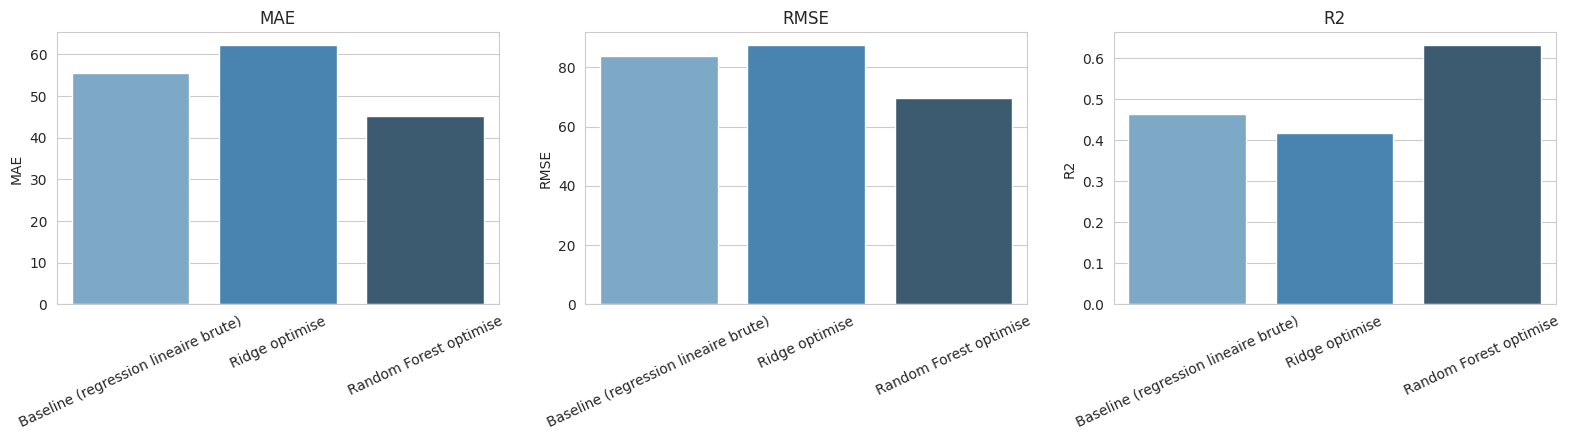

In [32]:
# Visualisation comparative des metriques
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, metrique in zip(axes, ['MAE', 'RMSE', 'R2']):
    sns.barplot(data=resultats, x='Modele', y=metrique, ax=ax, palette='Blues_d')
    ax.set_title(metrique)
    ax.tick_params(axis='x', rotation=25)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


**Interpretation comparative :**

- Le modele **Ridge optimise** n'ameliore pas la baseline, et la degrade meme legerement (R2 d'environ 0.42 contre 0.46 pour la baseline). Cela suggere que la relation entre les variables explicatives et la depense n'est pas purement lineaire, et que la regularisation, en contraignant les coefficients, ne suffit pas a compenser la perte des variables `gaming_addiction_risk_level` et `primary_game` retirees lors du nettoyage (rappelons que la baseline les conservait, avec le risque de fuite d'information identifie).
- Le modele **Random Forest optimise** ameliore nettement la performance par rapport a la baseline et au Ridge : le R2 passe a environ 0.63 (contre 0.46 pour la baseline), et la MAE diminue d'environ 55 a 45 dollars. Cela confirme l'hypothese formulee en EDA : il existe des **relations non lineaires et des effets d'interaction** entre les variables comportementales et sociales (temps de jeu, isolement, sommeil) que seul un modele non lineaire parvient a capturer efficacement.

**Nous retenons le modele Random Forest optimise comme modele final**, qui constitue le meilleur compromis entre performance predictive et respect de la logique metier (absence de fuite d'information, conservation des "Whales").


In [33]:
# Selection du modele final
modele_final = meilleur_rf
predictions_finales = pred_rf

print("=== Modele final retenu : Random Forest Regressor optimise ===")
print(f"Hyperparametres : {recherche_rf.best_params_}")
print()
print(f"MAE  : {mean_absolute_error(y_test, predictions_finales):.2f} USD")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, predictions_finales)):.2f} USD")
print(f"R2   : {r2_score(y_test, predictions_finales):.3f}")


=== Modele final retenu : Random Forest Regressor optimise ===
Hyperparametres : {'modele__max_depth': 5, 'modele__min_samples_leaf': 1, 'modele__n_estimators': 100}

MAE  : 45.15 USD
RMSE : 69.53 USD
R2   : 0.632


---
# Etape 4 : Validation et Interpretation

## 4.1 Analyse des residus

Pour un sujet de regression, l'analyse des residus (ecart entre valeur reelle et valeur predite) est essentielle pour juger de la qualite et de la fiabilite du modele, au-dela des seules metriques globales. Un bon modele doit produire des residus distribues de maniere aleatoire autour de zero, sans biais systematique.


In [34]:
# Calcul des residus du modele final sur l'ensemble de test
residus = y_test - predictions_finales

print("Statistiques descriptives des residus :")
print(residus.describe())
print()
print(f"Residu moyen : {residus.mean():.2f} USD (devrait etre proche de 0 si le modele est non biaise)")


Statistiques descriptives des residus :
count    200.000000
mean       5.768587
std       69.467652
min     -294.477260
25%      -22.709322
50%        5.595496
75%       32.531018
max      241.193686
Name: monthly_game_spending_usd, dtype: float64

Residu moyen : 5.77 USD (devrait etre proche de 0 si le modele est non biaise)


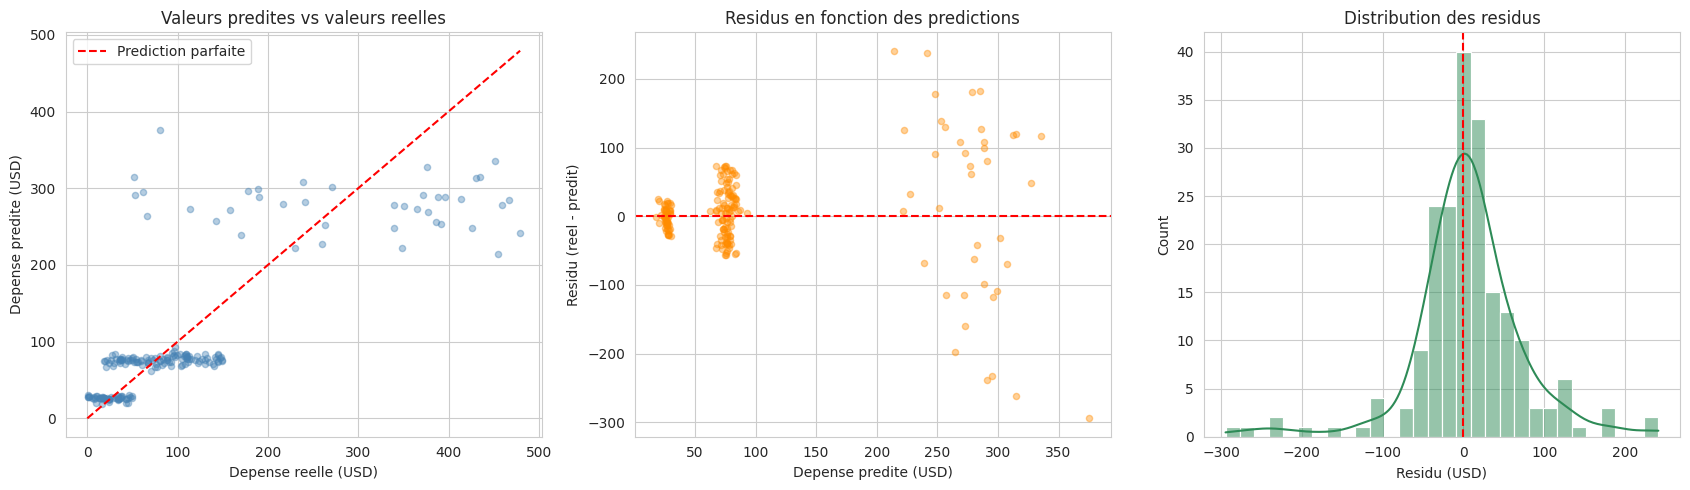

In [35]:
# Visualisation des residus : nuage de points (predit vs residu) et distribution
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Graphique 1 : valeurs predites vs valeurs reelles
axes[0].scatter(y_test, predictions_finales, alpha=0.4, s=20, color='steelblue')
limite = max(y_test.max(), predictions_finales.max())
axes[0].plot([0, limite], [0, limite], color='red', linestyle='--', label='Prediction parfaite')
axes[0].set_xlabel("Depense reelle (USD)")
axes[0].set_ylabel("Depense predite (USD)")
axes[0].set_title("Valeurs predites vs valeurs reelles")
axes[0].legend()

# Graphique 2 : residus en fonction des valeurs predites (detection de biais systematique)
axes[1].scatter(predictions_finales, residus, alpha=0.4, s=20, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Depense predite (USD)")
axes[1].set_ylabel("Residu (reel - predit)")
axes[1].set_title("Residus en fonction des predictions")

# Graphique 3 : distribution des residus
sns.histplot(residus, bins=30, kde=True, ax=axes[2], color='seagreen')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel("Residu (USD)")
axes[2].set_title("Distribution des residus")

plt.tight_layout()
plt.show()


**Interpretation de l'analyse des residus :**

- Le graphique "predit vs reel" montre que les points suivent globalement la diagonale pour les depenses faibles et moyennes, mais le modele a tendance a **sous-estimer les depenses les plus elevees** (les points des gros depensiers se situent plutot sous la diagonale rouge). C'est un biais systematique attendu et frequent avec les modeles de type Random Forest sur des cibles a distribution asymetrique : le modele a tendance a "tirer" ses predictions vers la moyenne et a sous-predire les valeurs extremes, faute d'avoir suffisamment d'exemples de "Whales" dans les donnees d'entrainement pour apprendre pleinement leur comportement specifique.
- Le graphique des residus en fonction des predictions confirme ce constat : on observe une **tendance des residus a devenir negatifs lorsque la prediction est elevee**, ce qui traduit precisement cette sous-estimation systematique des gros depensiers. Les residus ne sont donc pas parfaitement distribues de maniere aleatoire : il existe un biais structurel, lie a la rarete relative des "Whales" dans le jeu de donnees.
- La distribution des residus reste centree autour de 0 mais presente une asymetrie et une dispersion plus large vers les valeurs negatives extremes, coherente avec le biais identifie.

**Implication metier :** pour le cabinet de marketing, ce biais signifie que le modele actuel est fiable pour estimer la depense de la majorite des joueurs "moyens", mais qu'il a tendance a **sous-estimer le potentiel financier reel des "Whales"**. Si l'objectif principal est justement de cibler ces profils, ce biais devra etre signale explicitement dans toute utilisation operationnelle du modele, et pourrait justifier une etude complementaire dediee specifiquement a la sous-population des gros depensiers.


## 4.2 Courbe d'apprentissage (learning curve)

La courbe d'apprentissage permet de determiner si le modele souffre de sur-apprentissage (overfitting) et si l'ajout de davantage de donnees pourrait ameliorer ses performances.


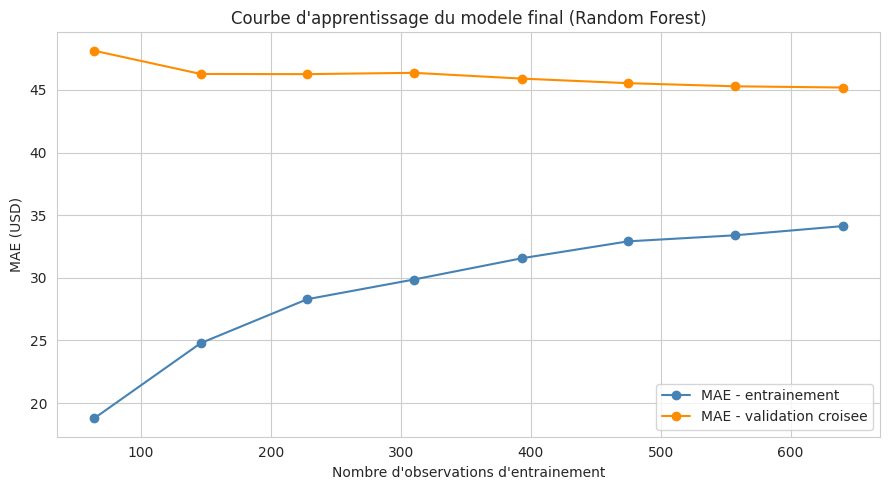

MAE entrainement par taille : [18.78 24.79 28.29 29.86 31.56 32.91 33.39 34.12]
MAE validation par taille   : [48.12 46.27 46.26 46.36 45.9  45.53 45.28 45.19]


In [36]:
# Calcul de la courbe d'apprentissage pour le modele final
tailles_train, scores_train, scores_val = learning_curve(
    modele_final, X_train, y_train, cv=5,
    scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1, random_state=RANDOM_STATE
)

mae_train_moyen = -scores_train.mean(axis=1)
mae_val_moyen = -scores_val.mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tailles_train, mae_train_moyen, marker='o', label='MAE - entrainement', color='steelblue')
ax.plot(tailles_train, mae_val_moyen, marker='o', label='MAE - validation croisee', color='darkorange')
ax.set_xlabel("Nombre d'observations d'entrainement")
ax.set_ylabel("MAE (USD)")
ax.set_title("Courbe d'apprentissage du modele final (Random Forest)")
ax.legend()
plt.tight_layout()
plt.show()

print("MAE entrainement par taille :", np.round(mae_train_moyen, 2))
print("MAE validation par taille   :", np.round(mae_val_moyen, 2))


**Interpretation de la courbe d'apprentissage :**

- L'erreur sur l'**ensemble d'entrainement** est nettement plus faible (environ 19 USD avec peu de donnees, jusqu'a environ 34 USD avec l'ensemble complet) que l'erreur en **validation croisee** (qui reste stable autour de 45-48 USD quelle que soit la taille de l'echantillon). Cet ecart persistant entre les deux courbes est le signe d'un **leger sur-apprentissage (overfitting)** : le modele apprend des regularites specifiques au train qui ne se generalisent pas integralement.
- Cependant, ce sur-apprentissage reste **mesure** : la profondeur maximale selectionnee par le GridSearch (`max_depth=5`) agit deja comme une regularisation efficace, ce qui explique que l'ecart ne se creuse pas davantage.
- Plus important : la courbe de validation **se stabilise et plafonne** a partir d'environ 300-400 observations d'entrainement, sans amelioration notable au-dela. Cela indique que **l'ajout de nouvelles donnees, a methodologie constante, n'apporterait probablement qu'un gain marginal** de performance. Pour ameliorer significativement le modele, il serait plus efficace d'investir dans l'**ingenierie de nouvelles variables** (par exemple des variables d'interaction explicites entre temps de jeu et isolement social) ou dans l'exploration d'autres familles de modeles (gradient boosting), plutot que dans la seule collecte de donnees supplementaires.


## 4.3 Importance des variables (feature importance)

Pour repondre directement a la question metier posee par le cabinet de marketing ("quels facteurs poussent les joueurs a depenser ?"), nous extrayons l'importance de chaque variable telle qu'apprise par le modele Random Forest final.


In [37]:
# Extraction des noms de variables apres pretraitement (encodage inclus)
noms_variables = modele_final.named_steps['pretraitement'].get_feature_names_out()
importances = modele_final.named_steps['modele'].feature_importances_

importance_variables = pd.Series(importances, index=noms_variables).sort_values(ascending=False)

# Affichage des 15 variables les plus importantes
print("Top 15 des variables les plus importantes pour predire la depense mensuelle :")
print(importance_variables.head(15))


Top 15 des variables les plus importantes pour predire la depense mensuelle :
num__daily_gaming_hours                   0.807677
num__face_to_face_social_hours_weekly     0.023512
num__sleep_hours                          0.016175
num__weight_change_kg                     0.014735
num__grades_gpa                           0.013890
num__exercise_hours_weekly                0.013148
cat__game_genre_Battle Royale             0.010030
num__age                                  0.009964
num__years_gaming                         0.009857
cat__game_genre_MMO                       0.009835
num__work_productivity_score              0.007883
num__social_isolation_score               0.006908
cat__sleep_disruption_frequency_Always    0.004754
cat__gender_Female                        0.003192
remainder__withdrawal_symptoms            0.002520
dtype: float64


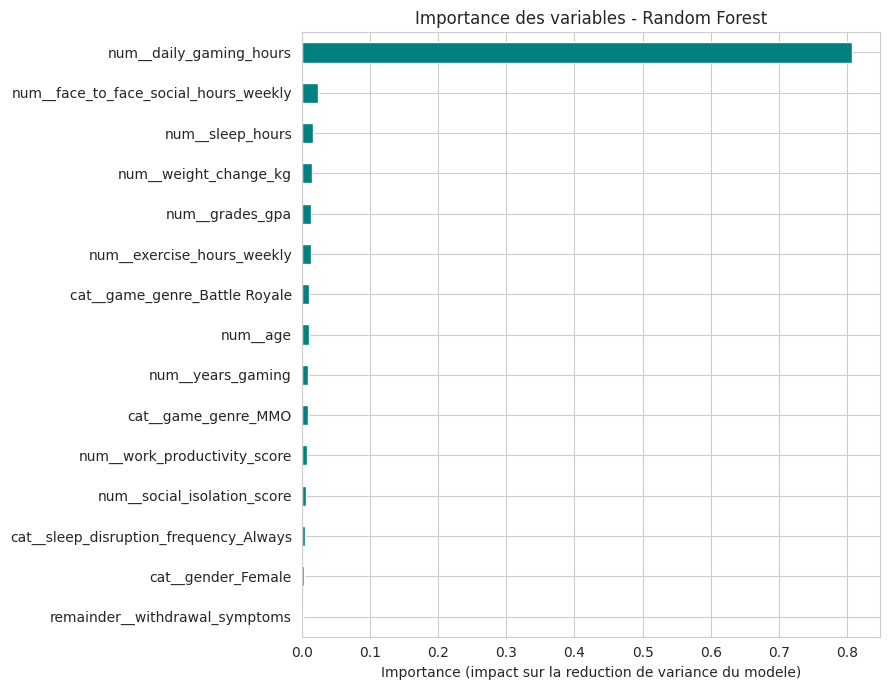

In [38]:
# Visualisation des 15 variables les plus importantes
fig, ax = plt.subplots(figsize=(9, 7))
importance_variables.head(15).sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel("Importance (impact sur la reduction de variance du modele)")
ax.set_title("Importance des variables - Random Forest")
plt.tight_layout()
plt.show()


**Interpretation pour le cabinet de marketing :**

- **`daily_gaming_hours` domine tres largement** toutes les autres variables, avec pres de 81% du poids decisionnel total du modele. C'est de loin le facteur le plus determinant : **le temps de jeu quotidien est le predicteur numero un de la depense mensuelle**. Un joueur qui passe plus de temps en jeu y investit logiquement aussi plus d'argent (achats in-game, abonnements, contenus additionnels).
- Viennent ensuite, avec un poids beaucoup plus faible mais non negligeable, `face_to_face_social_hours_weekly` (vie sociale physique), `sleep_hours` (sommeil), `weight_change_kg` et `exercise_hours_weekly` : ces variables confirment le profil du "Whale" identifie en EDA, a savoir un joueur dont le mode de vie global est tres centre sur le jeu, au detriment du sommeil, du sport et de la socialisation physique.
- Le genre de jeu (`game_genre`), en particulier Battle Royale et MMO, ressort egalement parmi les variables informatives, confirmant l'intuition issue de l'EDA sur les differences de modeles economiques entre genres de jeux.

**Recommandation pour le ciblage marketing :** le facteur le plus actionnable et le plus predictif reste le **temps de jeu quotidien**. Un profil combinant un temps de jeu eleve, une vie sociale physique faible et un genre de jeu a forte monetisation (Battle Royale, MMO) constitue le signal le plus fort pour identifier un "Whale" potentiel.


## 4.4 Interpretation des metriques d'evaluation au regard du contexte metier

Le modele final obtient un **R2 d'environ 0,63** et une **MAE d'environ 45 dollars**. Que signifient ces chiffres pour le cabinet de marketing ?

- Un **R2 de 0,63** signifie que le modele explique environ 63% de la variabilite de la depense mensuelle des joueurs a partir des variables comportementales et demographiques disponibles. Le reste (37%) releve de facteurs non captures par ce jeu de donnees (pouvoir d'achat individuel, contexte familial, evenements promotionnels specifiques au jeu, impulsivite personnelle, etc.). C'est un niveau de performance correct mais pas excellent pour un usage purement predictif individuel ; il est en revanche tout a fait suffisant pour un usage de **segmentation et de priorisation marketing**, qui ne necessite pas une precision au dollar pres mais une bonne capacite a distinguer les profils a fort potentiel des profils a faible potentiel.
- Une **MAE de 45 dollars** doit etre relativisee par rapport a la depense mediane observee (environ 66 dollars) : l'erreur moyenne represente donc une part significative de la depense typique. Le modele est donc plus utile pour un **classement relatif des joueurs** (identifier qui depense le plus) que pour une **estimation absolue precise** du montant exact qu'un joueur va depenser.
- Le biais identifie dans l'analyse des residus (sous-estimation des plus gros depensiers) doit etre garde en tete : dans une optique de ciblage des "Whales", il est preferable d'interpreter les sorties du modele comme un **minorant** plutot qu'une estimation exacte de leur potentiel de depense reel.


## 4.5 Prediction sur un cas personnel

Conformement aux consignes, nous appliquons le modele final a un profil personnel afin d'estimer une depense mensuelle de jeu video, puis nous discutons de la coherence de cette prediction.

Le profil ci-dessous est construit a titre d'exemple representatif d'un profil etudiant raisonnable (peu de temps de jeu quotidien, sommeil correct, vie sociale active). **Chaque valeur peut etre librement modifiee** dans le dictionnaire `mon_profil` ci-dessous pour correspondre exactement a votre propre situation, et obtenir une prediction personnalisee.


In [39]:
# Construction d'un profil personnel a soumettre au modele
# Toutes les valeurs ci-dessous peuvent etre adaptees a votre propre situation reelle

mon_profil = pd.DataFrame([{
    'age': 24,
    'gender': 'Male',
    'daily_gaming_hours': 1.5,                 # heures de jeu quotidiennes
    'game_genre': 'Strategy',
    'gaming_platform': 'PC',
    'sleep_hours': 7.0,
    'sleep_quality': 'Good',
    'sleep_disruption_frequency': 'Rarely',
    'academic_work_performance': 'Good',
    'grades_gpa': 0,                            # 0 car non etudiant au sens GPA (cf. is_student)
    'work_productivity_score': 7,
    'mood_state': 'Normal',
    'mood_swing_frequency': 'Rarely',
    'withdrawal_symptoms': 0,
    'loss_of_other_interests': 0,
    'continued_despite_problems': 0,
    'eye_strain': 0,
    'back_neck_pain': 0,
    'weight_change_kg': 0.0,
    'exercise_hours_weekly': 4.0,
    'social_isolation_score': 2,                # echelle de 1 (faible) a 10 (fort isolement)
    'face_to_face_social_hours_weekly': 10.0,
    'years_gaming': 8,
    'is_student': 1                             # 1 = etudiant (utilise grades_gpa), 0 = actif (utilise work_productivity_score)
}])

# On reordonne les colonnes pour qu'elles correspondent exactement a celles utilisees a l'entrainement
mon_profil = mon_profil[X.columns]

# Prediction du modele final
prediction_personnelle = modele_final.predict(mon_profil)[0]

print(f"Depense mensuelle predite pour ce profil : {prediction_personnelle:.2f} USD")
print(f"Pour comparaison, la depense mediane observee dans le jeu de donnees est de {y.median():.2f} USD")


Depense mensuelle predite pour ce profil : 25.48 USD
Pour comparaison, la depense mediane observee dans le jeu de donnees est de 66.41 USD


**Discussion de la coherence de la prediction :**

Pour le profil exemple ci-dessus (temps de jeu modere de 1,5h/jour, bon sommeil, vie sociale physique active, faible isolement social), le modele predit une depense mensuelle nettement **inferieure a la mediane** du jeu de donnees. Cette prediction est coherente avec l'analyse d'importance des variables menee precedemment : puisque `daily_gaming_hours` est de tres loin le facteur le plus determinant, et que ce profil presente un temps de jeu faible par rapport a la moyenne de l'echantillon (6,15h/jour en moyenne dans le dataset), il est logique que le modele predise une depense faible.

Cette coherence interne valide la logique du modele : il ne s'agit pas d'une prediction arbitraire, mais bien le reflet direct de la relation forte identifiee entre temps de jeu et depense.

**A noter pour une utilisation personnalisee :** si vous renseignez vos propres valeurs reelles dans le dictionnaire `mon_profil`, gardez a l'esprit le biais identifie en section 4.1 : si votre profil se rapproche de celui d'un gros joueur (`daily_gaming_hours` eleve, `social_isolation_score` eleve), le modele aura tendance a **sous-estimer legerement** votre depense reelle potentielle.


---
# Conclusion générale

Cette étude de cas a permis de repondre a l'objectif fixe par le cabinet de conseil en marketing : identifier les facteurs qui expliquent la depense mensuelle des joueurs et construire un modèle predictif exploitable pour le ciblage des profils "Whales".

**Principaux enseignements :**

1. **Le temps de jeu quotidien est, de très loin, le facteur le plus determinant** de la depense mensuelle, suivi par des facteurs liés au mode de vie global (vie sociale physique, sommeil, activite physique).
2. La distribution de la dépense est fortement asymetrique, avec une minorité de gros dépensiers ("Whales") qu'il a été deliberement decide de **conserver** dans l'analyse plutot que de les traiter comme des outliers a supprimer, ce choix étant directement justifié par l'objectif métier de l'étude.
3. Les valeurs manquantes observées sur `grades_gpa` et `work_productivity_score` se sont reveles etre **structurelles** (liées au statut étudiant/actif) plutot qu'aleatoires, ce qui a motive une strategie d'imputation specifique préservant cette information via la variable `is_student`.
4. Le modèle **Random Forest optimise** (R2 = 0,63, MAE = 45 USD) surpasse nettement la baseline linéaire et un modele Ridge regularise, confirmant la présence de relations non linéaires et d'intéractions entre variables comportementales.
5. L'analyse des residus revèle un **biais de sous-éstimation systematique pour les plus gros dépensiers**, point de vigilance essentiel pour toute utilisation opérationnelle du modèle dans un objectif de ciblage marketing des "Whales".

**Limites et pistes d'amélioration :** la courbe d'apprentissage suggère qu'une simple augmentation du volume de données n'ameliorerait que marginalement la performance. Des pistes plus prometteuses incluraient la création de variables d'intéraction explicites (par exemple croisement temps de jeu x isolement social), le test de modeles de gradient boosting (XGBoost, LightGBM), ou encore une modelisation specifique et dediée a la sous-population des gros depensiers, segment le plus intéressant pour le cabinet de marketing mais aussi le moins bien predit par le modele actuel.
